# Logistic Regression from Scratch

In this exercise, you'll implement logistic regression using only NumPy.
You'll learn about:
- The sigmoid activation function
- Binary cross-entropy loss
- Gradient computation (backpropagation)
- Parameter updates using gradient descent

## BACKGROUND:
-----------
Logistic regression is used for binary classification (predicting 0 or 1).
Given input features x, we want to predict the probability that y = 1.

The model computes:
1. z = x · W + b  (linear combination)
2. ŷ = σ(z)       (apply sigmoid to get probability)
3. prediction = 1 if ŷ ≥ 0.5, else 0

Where σ(z) = 1 / (1 + e^(-z)) is the sigmoid function.

## YOUR TASKS:
-----------
Complete the functions marked with TODO comments below.

## GRADIENT DESCENT ALGORITHM:

The learning process consists of iterating these steps:

**Step 1: Forward Pass**
- Compute predictions: ŷ = σ(x·W + b)

**Step 2: Compute Loss**
- Measure error: L = -1/m * Σ[y·log(ŷ) + (1-y)·log(1-ŷ)]

**Step 3: Backward Pass**
- Calculate gradients: ∂L/∂W and ∂L/∂b
- These tell us which direction increases the loss

**Step 4: Update Parameters**
- Move opposite to gradient: W = W - α·∂L/∂W
- This decreases the loss

**Repeat until loss stops decreasing!**

### WHY IT WORKS

- Gradients point **uphill** (toward higher loss)
- We move **downhill** (opposite direction) to minimize loss
- Learning rate α controls step size
- Eventually we reach a minimum (valley)

In [1]:
import numpy as np

class LogisticRegressionNumpy:
    def __init__(self, input_dim, output_dim):
        """
        Initialize weights and bias with small random values.
        
        Args:
            input_dim: Number of input features
            output_dim: Number of output classes (1 for binary classification)
        """
        # Initialize weights with small random values (helps with training)
        self.W = np.random.randn(input_dim, output_dim) * 0.01
        # Initialize bias to zeros
        self.b = np.zeros((1, output_dim))
    
    # ========================================
    # TASK 1: Implement the Sigmoid Function
    # ========================================
    def sigmoid(self, z):
        """
        Compute the sigmoid activation function: σ(z) = 1 / (1 + e^(-z))
        
        The sigmoid function:
        - Takes any real number as input
        - Outputs a value between 0 and 1
        - Used to convert linear outputs to probabilities
        
        IMPORTANT: For numerical stability, clip z to prevent overflow!
        Very large positive/negative values can cause exp() to overflow.
        
        Args:
            z: Input values (can be scalar, vector, or matrix)
        
        Returns:
            Sigmoid of z, same shape as input
        
        HINT: Use np.clip() to limit z to range [-500, 500]
        HINT: Formula is 1 / (1 + np.exp(-z))
        """
        # TODO: Implement sigmoid function with numerical stability
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    # ========================================
    # TASK 2: Implement Forward Pass
    # ========================================
    def forward(self, x):
        """
        Compute predictions using the formula: ŷ = σ(x · W + b)
        
        This is called the "forward pass" because we're moving forward
        through the network from inputs to outputs.
        
        Steps:
        1. Compute linear combination: z = x · W + b
        2. Apply sigmoid activation: ŷ = σ(z)
        
        Args:
            x: Input features, shape (m, input_dim) where m is number of samples
        
        Returns:
            y_pred: Predicted probabilities, shape (m, output_dim)
        
        HINT: Use np.dot() for matrix multiplication
        HINT: Call self.sigmoid() to apply activation
        """
        # TODO: Implement forward pass
        # Step 1: Compute linear combination z = x·W + b
        z = np.dot(x, self.W) + self.b
        # Step 2: Apply sigmoid activation
        return self.sigmoid(z)
    
    # ========================================
    # TASK 3: Implement Loss Function
    # ========================================
    def compute_loss(self, y_pred, y_true):
        """
        Compute binary cross-entropy loss (log loss).
        
        This measures how well our predictions match the true labels.
        Lower loss = better predictions.
        
        Formula: L = -1/m * Σ[y·log(ŷ) + (1-y)·log(1-ŷ)]
        
        Where:
        - m is the number of samples
        - y is the true label (0 or 1)
        - ŷ is our predicted probability
        
        Intuition: 
        - If y=1 and ŷ→1: -log(ŷ)→0 (good, low loss)
        - If y=1 and ŷ→0: -log(ŷ)→∞ (bad, high loss)
        
        Args:
            y_pred: Predicted probabilities, shape (m, 1)
            y_true: True labels (0 or 1), shape (m,) or (m, 1)
        
        Returns:
            loss: Average loss across all samples (scalar)
        
        HINT: Use np.clip() to avoid log(0), clip y_pred to [1e-15, 1-1e-15]
        HINT: Use y_true.reshape(-1, 1) to ensure shapes match
        HINT: Use np.mean() to average over all samples
        """
        # TODO: Implement binary cross-entropy loss
        m = y_true.shape[0]  # Number of samples
        
        # Clip predictions to avoid log(0) which would give -inf
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        
        # Reshape y_true to match y_pred if needed
        y_true = y_true.reshape(-1, 1)
        
        # Binary cross-entropy formula
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        
        return loss
    
    # ========================================
    # TASK 4: Implement Backward Pass
    # ========================================
    def backward(self, x, y_pred, y_true):
        """
        Compute gradients using backpropagation.
        
        This is the "backward pass" - we compute how much each parameter
        contributed to the error, so we know how to adjust them.
        
        The gradients tell us:
        - Direction to move parameters (+ or -)
        - How much to move them (magnitude)
        
        Mathematical derivation (using chain rule):
        - dL/dW = 1/m * x^T · (ŷ - y)
        - dL/db = 1/m * Σ(ŷ - y)
        
        Where:
        - ŷ - y is the error (prediction - truth)
        - x^T is the transpose of input features
        - m is the number of samples
        
        Args:
            x: Input features, shape (m, input_dim)
            y_pred: Predicted probabilities, shape (m, 1)
            y_true: True labels, shape (m,) or (m, 1)
        
        Returns:
            dW: Gradient w.r.t. weights, shape (input_dim, output_dim)
            db: Gradient w.r.t. bias, shape (1, output_dim)
        
        HINT: First reshape y_true to match y_pred shape
        HINT: dz = y_pred - y_true (the error)
        HINT: dW = np.dot(x.T, dz) / m
        HINT: db = np.sum(dz, axis=0, keepdims=True) / m
        """
        # TODO: Implement gradient computation
        m = y_true.shape[0]  # Number of samples
        
        # Reshape y_true to match y_pred
        y_true = y_true.reshape(-1, 1)
        
        # Gradient of loss w.r.t. predictions (the error term)
        # For binary cross-entropy with sigmoid, this simplifies to: ŷ - y
        dz = y_pred - y_true
        
        # Gradient w.r.t. weights: dL/dW = (1/m) * X^T · dz
        dW = np.dot(x.T, dz) / m
        
        # Gradient w.r.t. bias: dL/db = (1/m) * Σ(dz)
        db = np.sum(dz, axis=0, keepdims=True) / m
        
        return dW, db
    
    # ========================================
    # TASK 5: Implement Parameter Update
    # ========================================
    def update_params(self, dW, db, learning_rate):
        """
        Update weights and bias using gradient descent.
        
        Gradient descent moves parameters in the opposite direction of the gradient
        to minimize the loss. Think of it like walking downhill to find the valley.
        
        Update rule:
        - W = W - α · dW
        - b = b - α · db
        
        Where α (alpha) is the learning rate:
        - Too large: might overshoot the minimum
        - Too small: training takes forever
        - Typical values: 0.001 to 0.1
        
        Args:
            dW: Gradient of loss w.r.t. weights
            db: Gradient of loss w.r.t. bias
            learning_rate: Step size for parameter updates
        
        HINT: Subtract learning_rate * gradient from each parameter
        """
        # TODO: Implement parameter updates
        # Move parameters in opposite direction of gradient
        self.W -= learning_rate * dW
        self.b -= learning_rate * db
    
    def predict(self, x):
        """
        Make binary predictions (0 or 1).
        
        This function is already implemented for you.
        It uses a threshold of 0.5: if probability ≥ 0.5, predict 1, else 0.
        
        Args:
            x: Input features
        
        Returns:
            predictions: Binary predictions (0 or 1)
        """
        y_pred = self.forward(x)
        return (y_pred >= 0.5).astype(int)

In [2]:
# ========================================
# TRAINING FUNCTION
# ========================================

def train_logistic_regression(model, x_train, y_train, x_test, y_test, 
                              learning_rate=0.01, n_epochs=4000, freq_print=200):
    """
    Train logistic regression model and track metrics.
    
    Args:
        model: LogisticRegressionNumpy instance
        x_train, y_train: Training data
        x_test, y_test: Test data
        learning_rate: Learning rate for gradient descent
        n_epochs: Number of training iterations
        freq_print: How often to print statistics
    
    Returns:
        Training history (losses, accuracies, iterations)
    """
    losses = []
    losses_test = []
    accuracies_train = []
    accuracies_test = []
    iterations = []
    
    for epoch in range(n_epochs):
        # Forward pass
        y_pred_train = model.forward(x_train)
        
        # Compute loss
        loss_train = model.compute_loss(y_pred_train, y_train)
        
        # Backward pass
        dW, db = model.backward(x_train, y_pred_train, y_train)
        
        # Update parameters
        model.update_params(dW, db, learning_rate)
        
        # Print statistics every freq_print iterations
        if (epoch + 1) % freq_print == 0:
            # Test set evaluation
            y_pred_test = model.forward(x_test)
            loss_test = model.compute_loss(y_pred_test, y_test)
            
            # Calculate accuracies
            pred_train = model.predict(x_train)
            accuracy_train = 100 * np.mean(pred_train.flatten() == y_train)
            
            pred_test = model.predict(x_test)
            accuracy_test = 100 * np.mean(pred_test.flatten() == y_test)
            
            # Store metrics
            losses.append(loss_train)
            losses_test.append(loss_test)
            accuracies_train.append(accuracy_train)
            accuracies_test.append(accuracy_test)
            iterations.append(epoch + 1)
            
            print(f"Iteration: {epoch + 1}")
            print(f"Test  - Loss: {loss_test:.4f}, Accuracy: {accuracy_test:.2f}%")
            print(f"Train - Loss: {loss_train:.4f}, Accuracy: {accuracy_train:.2f}%\n")
    
    return losses, losses_test, accuracies_train, accuracies_test, iterations


In [3]:
from sklearn.metrics import accuracy_score
from sklearn import datasets, model_selection
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
# Load the Iris dataset
iris = datasets.load_iris()
data = iris.data[:, :2]  # Only sepal length and width
targets = iris.target

# Convert to binary classification
targets_binary = np.where(targets == 0, 0, 1)

# Split into train and test sets
x_train, x_test, y_train, y_test = model_selection.train_test_split(
    data, targets_binary, test_size=0.2, random_state=42
)

In [5]:
# Initialize model
model = LogisticRegressionNumpy(input_dim=2, output_dim=1)

# Train model with smaller learning rate
losses, losses_test, acc_train, acc_test, iterations = train_logistic_regression(
    model, x_train, y_train, x_test, y_test,
    learning_rate=0.01,  
    n_epochs=4000, 
    freq_print=200
)

Iteration: 200
Test  - Loss: 0.5195, Accuracy: 66.67%
Train - Loss: 0.5169, Accuracy: 66.67%

Iteration: 400
Test  - Loss: 0.4514, Accuracy: 70.00%
Train - Loss: 0.4434, Accuracy: 72.50%

Iteration: 600
Test  - Loss: 0.3994, Accuracy: 76.67%
Train - Loss: 0.3877, Accuracy: 89.17%

Iteration: 800
Test  - Loss: 0.3588, Accuracy: 80.00%
Train - Loss: 0.3447, Accuracy: 94.17%

Iteration: 1000
Test  - Loss: 0.3265, Accuracy: 83.33%
Train - Loss: 0.3109, Accuracy: 95.83%

Iteration: 1200
Test  - Loss: 0.3002, Accuracy: 100.00%
Train - Loss: 0.2837, Accuracy: 97.50%

Iteration: 1400
Test  - Loss: 0.2784, Accuracy: 100.00%
Train - Loss: 0.2614, Accuracy: 97.50%

Iteration: 1600
Test  - Loss: 0.2600, Accuracy: 100.00%
Train - Loss: 0.2428, Accuracy: 97.50%

Iteration: 1800
Test  - Loss: 0.2444, Accuracy: 100.00%
Train - Loss: 0.2272, Accuracy: 98.33%

Iteration: 2000
Test  - Loss: 0.2308, Accuracy: 100.00%
Train - Loss: 0.2138, Accuracy: 98.33%

Iteration: 2200
Test  - Loss: 0.2190, Accuracy: 1

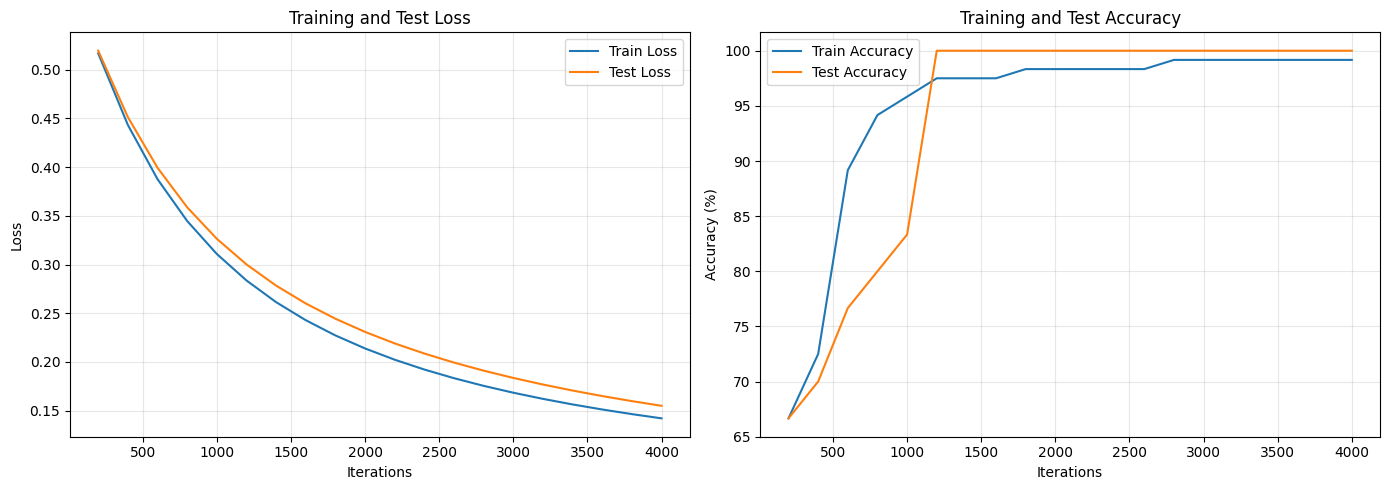

In [6]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(iterations, losses, label='Train Loss')
ax1.plot(iterations, losses_test, label='Test Loss')
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(iterations, acc_train, label='Train Accuracy')
ax2.plot(iterations, acc_test, label='Test Accuracy')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

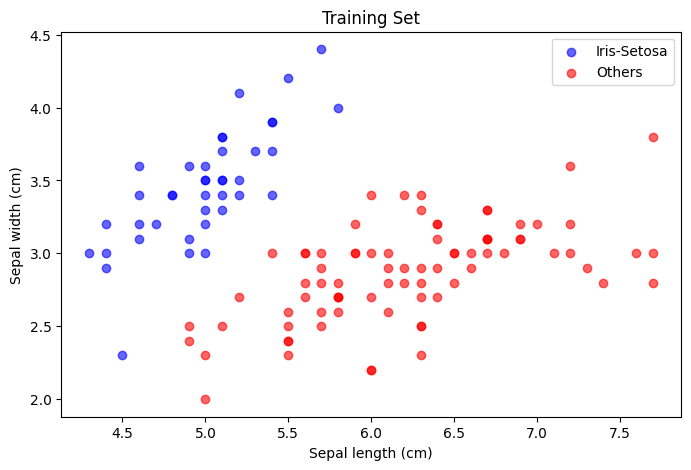

In [7]:
# Visualize the training data
labels = {0: 'Iris-Setosa', 1: 'Others'}
colors = ['blue', 'red']

plt.figure(figsize=(8, 5))
for c in [0, 1]:
    mask = y_train == c
    plt.scatter(x_train[mask, 0], x_train[mask, 1], 
                label=labels[c], c=colors[c], alpha=0.6)

plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Training Set")
plt.legend()
plt.show()

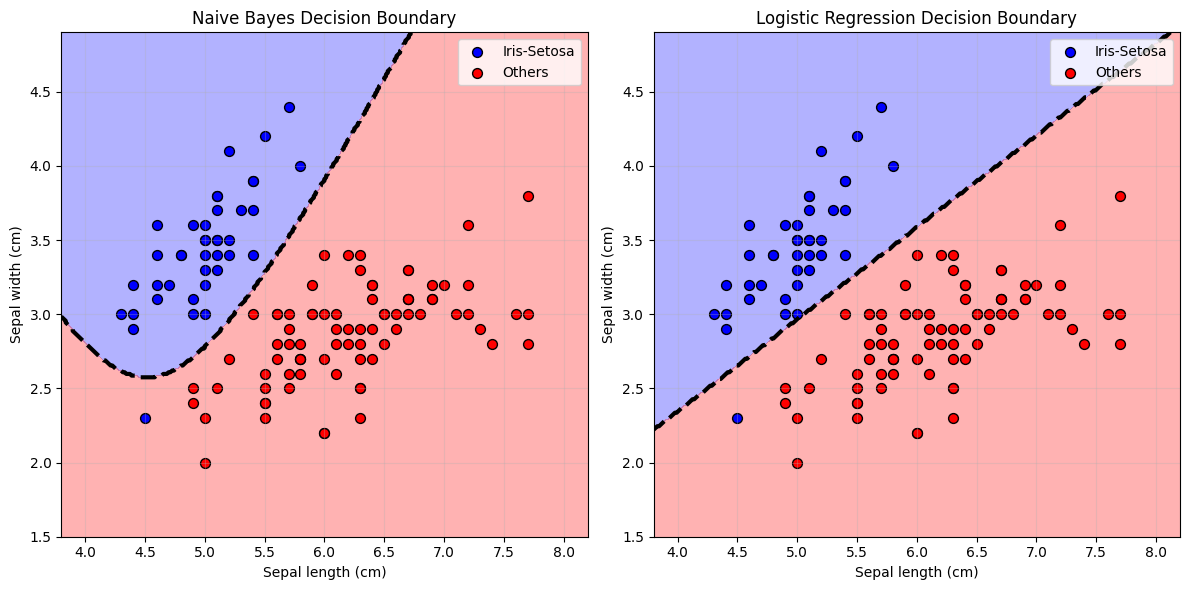

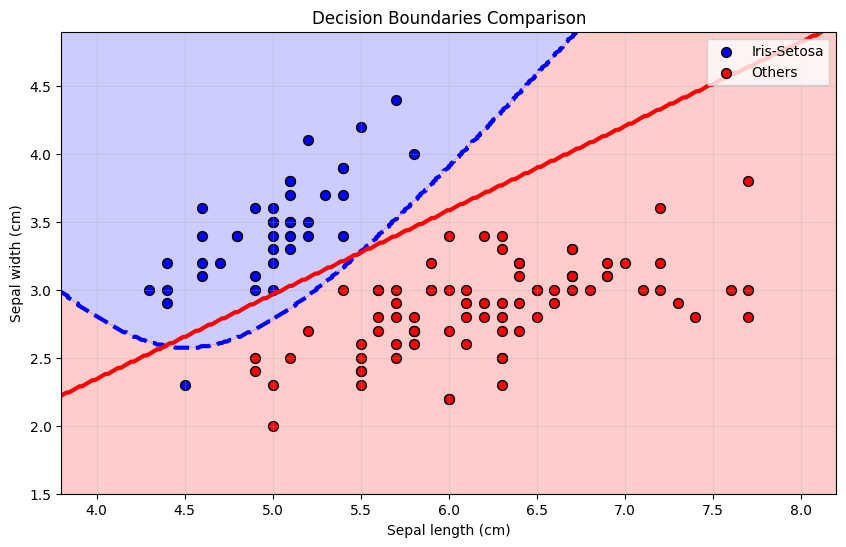

Naive Bayes Test Accuracy: 100.00%
Logistic Regression Test Accuracy: 100.00%


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.naive_bayes import GaussianNB

# Train sklearn's Naive Bayes
sklearn_nb = GaussianNB()
sklearn_nb.fit(x_train, y_train)

# Create mesh grid
x0_min, x0_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
x1_min, x1_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 300),
                        np.linspace(x1_min, x1_max, 300))
mesh_points = np.c_[xx0.ravel(), xx1.ravel()]


# Get Naive Bayes predictions
Z_nb = sklearn_nb.predict(mesh_points)
Z_nb = Z_nb.reshape(xx0.shape)

# Get Logistic Regression predictions 
Z_lr = model.predict(mesh_points)
Z_lr = Z_lr.reshape(xx0.shape)

# Create the plot
plt.figure(figsize=(12, 6))

# Plot 1: Naive Bayes
plt.subplot(1, 2, 1)
plt.contourf(xx0, xx1, Z_nb, alpha=0.3, colors=colors, levels=[-0.5, 0.5, 1.5])
for c in [0, 1]:
    mask = y_train == c
    plt.scatter(x_train[mask, 0], x_train[mask, 1], 
                label=labels[c], c=colors[c], edgecolor='k', s=50)
plt.contour(xx0, xx1, Z_nb, levels=[0.5], colors='black', linewidths=3, linestyles='--')
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Naive Bayes Decision Boundary")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Logistic Regression
plt.subplot(1, 2, 2)
plt.contourf(xx0, xx1, Z_lr, alpha=0.3, colors=colors, levels=[-0.5, 0.5, 1.5])
for c in [0, 1]:
    mask = y_train == c
    plt.scatter(x_train[mask, 0], x_train[mask, 1], 
                label=labels[c], c=colors[c], edgecolor='k', s=50)
plt.contour(xx0, xx1, Z_lr, levels=[0.5], colors='black', linewidths=3, linestyles='--')
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Combined plot showing both boundaries
plt.figure(figsize=(10, 6))
plt.contourf(xx0, xx1, Z_nb, alpha=0.2, colors=colors, levels=[-0.5, 0.5, 1.5])

for c in [0, 1]:
    mask = y_train == c
    plt.scatter(x_train[mask, 0], x_train[mask, 1], 
                label=labels[c], c=colors[c], edgecolor='k', s=50)

# Plot both decision boundaries
plt.contour(xx0, xx1, Z_nb, levels=[0.5], colors='blue', linewidths=3, 
            linestyles='--')
plt.contour(xx0, xx1, Z_lr, levels=[0.5], colors='red', linewidths=3, 
            linestyles='-')

# Create custom legend entries for the decision boundaries
legend_elements = [
    Line2D([0], [0], color='blue', linewidth=3, linestyle='--', label='Naive Bayes'),
    Line2D([0], [0], color='red', linewidth=3, linestyle='-', label='Logistic Regression'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[0], 
           markersize=10, markeredgecolor='k', label=labels[0]),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[1], 
           markersize=10, markeredgecolor='k', label=labels[1])
]

plt.legend(handles=legend_elements, loc='best')
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Decision Boundaries Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print accuracies for comparison
nb_pred = sklearn_nb.predict(x_test)
lr_pred = model.predict(x_test).flatten()

print(f"Naive Bayes Test Accuracy: {100 * np.mean(nb_pred == y_test):.2f}%")
print(f"Logistic Regression Test Accuracy: {100 * np.mean(lr_pred == y_test):.2f}%")